Peso das classes balanceadas: {0: np.float64(0.7671428571428571), 1: np.float64(1.4358288770053476)}

TESTANDO ARQUITETURA: [12, 8]
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 24.
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
MÉDIAS DA ARQUITETURA [12, 8]:
Acurácia: 0.6649 | Precisão: 0.5248 | Recall: 0.7060


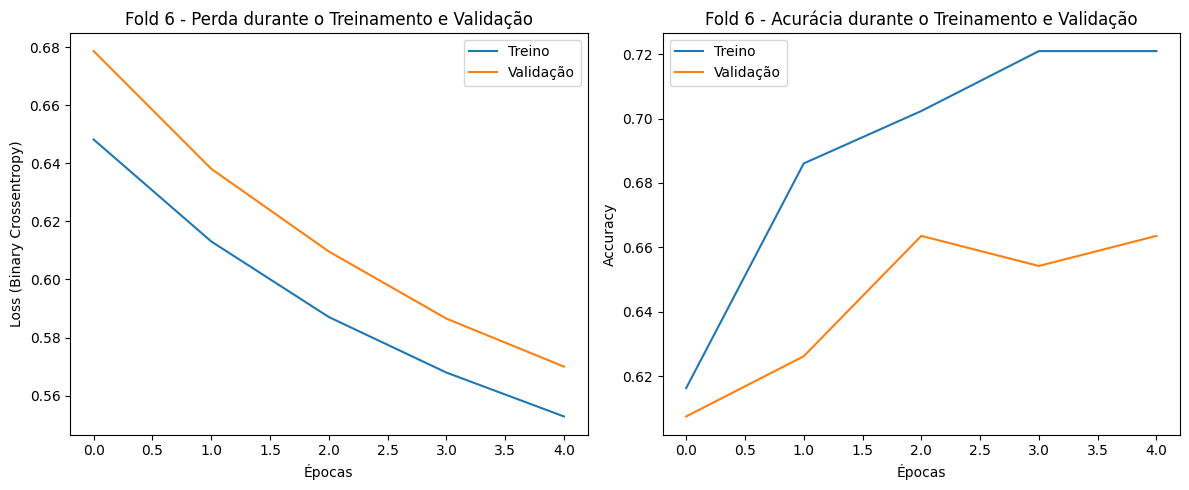

Resultados para o Fold 6:
  Acurácia: 0.6075
  Precisão: 0.4545
  Recall: 0.6757


TESTANDO ARQUITETURA: [32, 16]
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 20.
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 19.
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
MÉDIAS DA ARQUITETURA [32, 16]:
Acurácia: 0.6908 | Precisão: 0.5744 | Recall: 0.7441


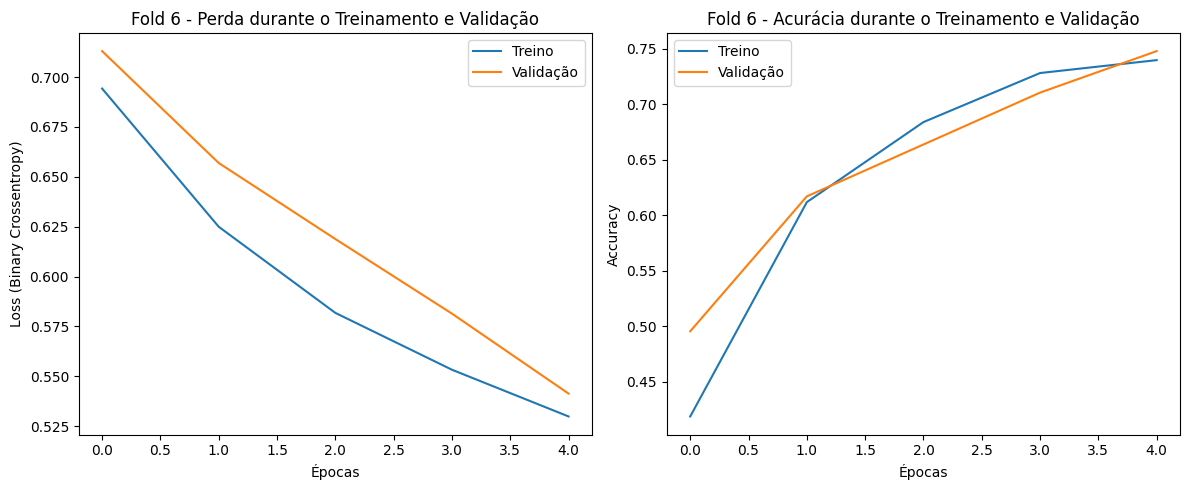

Resultados para o Fold 6:
  Acurácia: 0.4953
  Precisão: 0.4000
  Recall: 0.9189


TESTANDO ARQUITETURA: [16, 8, 4]
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 13.
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 27.
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
MÉDIAS DA ARQUITETURA [16, 8, 4]:
Acurácia: 0.5860 | Precisão: 0.4492 | Recall: 0.6299


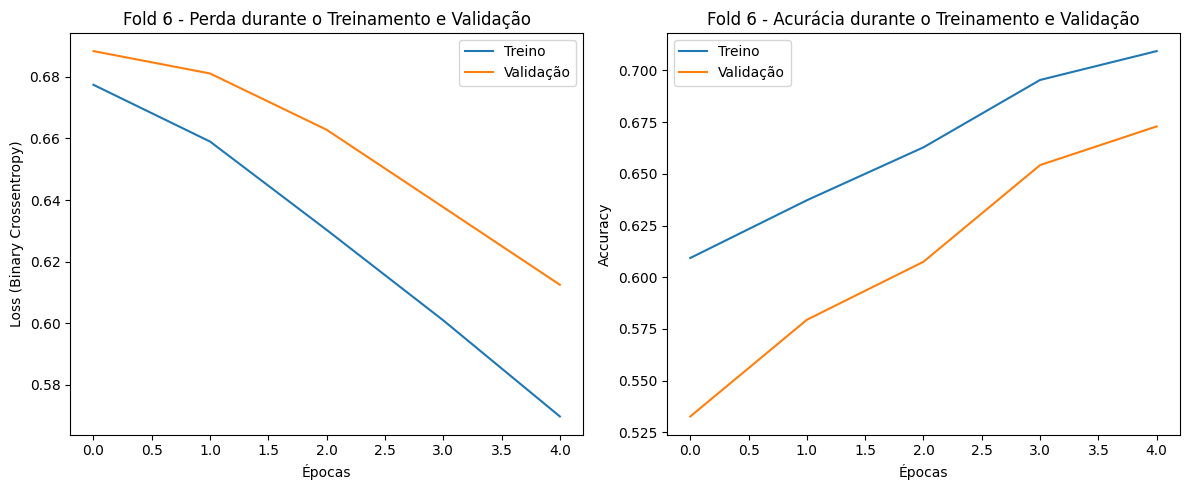

Resultados para o Fold 6:
  Acurácia: 0.5327
  Precisão: 0.3243
  Recall: 0.3243


**************************************************
A ARQUITETURA VENCEDORA FOI: [32, 16]
**************************************************
-- MÉDIA DOS RESULTADOS APÓS VALIDAÇÃO CRUZADA --
Acurácia média: 0.5860
Precisão média: 0.4492
Recall média: 0.6299

-- USANDO O MELHOR MODELO (menor val_loss) PARA AVALIAÇÃO EM TESTES --
 -- RESULTADOS DO MELHOR MODELO NOS DADOS DE TESTE --
  Teste - Perda: 0.4841
  Teste - Acurácia: 0.7532
  Teste - Precisão: 0.6429
  Teste - Recall: 0.6667

Estudo com Threshold > 0.3

Confusion Matrix:
[[95 55]
 [10 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.63      0.75       150
           1       0.56      0.88      0.69        81

    accuracy                           0.72       231
   macro avg       0.73      0.75      0.72       231
weighted avg       0.79      0.72      0.72       231

Accuracy: 0.71

In [6]:
# -*- coding: utf-8 -*-
"""
Created on Tue Jul 16 11:31:22 2024

@author: Karla Figueiredo
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.datasets import make_classification # Importing make_classification
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score # Importing evaluation metrics
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K


# ==========================================
# 1. IMPORTAÇÃO E PREPARAÇÃO DOS DADOS
# ==========================================

# Definir o nome das colunas da base de dados
colunas = [
    "Pregnancies", "Glucose", "BloodPressure",
    "SkinThickness", "Insulin", "BMI",
    "DiabetesPedigreeFunction", "Age", "Outcome"
]

# Carregar a base de dados
df = pd.read_csv("pima.csv", sep=";", header=None, names=colunas)
X = df.drop(columns=["Outcome"]).to_numpy(dtype=np.float32)
y = df["Outcome"].to_numpy(dtype=np.int32)

# Dividir o conjunto de dados em treinamento e teste com amostragem estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# ==========================================
# 2. PRÉ-PROCESSAMENTO
# ==========================================

# Substituir zeros por NaN nas colunas onde 0 é impossível
cols_com_zeros_invalidos = [1, 2, 3, 4, 5]  # Índices de Glucose, BloodPressure, SkinThickness, Insulin, BMI
X_train[:, cols_com_zeros_invalidos] = np.where(X_train[:, cols_com_zeros_invalidos] == 0, np.nan, X_train[:, cols_com_zeros_invalidos])
X_test[:, cols_com_zeros_invalidos] = np.where(X_test[:, cols_com_zeros_invalidos] == 0, np.nan, X_test[:, cols_com_zeros_invalidos])

# Imputar os dados faltantes (NaN) com a mediana de cada coluna do conjunto de treino
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Normalizar os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Calcular pesos das classes
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(f"Peso das classes balanceadas: {class_weights_dict}")

# ==========================================
# 3. BUSCA DE HIPERPARÂMETROS
# ==========================================

# Arquiteturas a serem testadas
arquiteturas = [
    [12, 8],
    [32, 16],
    [16, 8, 4]
]

campea_val_loss = np.inf
modelo_campeao_global = None
nome_campea = ""

# Loop pelas arquiteturas
for arq in arquiteturas:
    print(f"\n{'='*50}")
    print(f"TESTANDO ARQUITETURA: {arq}")
    print(f"{'='*50}")

    # Configuração da validação cruzada
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation com estratificação
    fold_no = 1  # Número do fold para rastreamento

    # Listas para armazenar as métricas por fold
    accuracy_per_fold = []
    precision_per_fold = []
    recall_per_fold = []
    val_loss_per_fold = []  # Armazena o val_loss de cada fold para escolher o melhor modelo
    best_val_loss_arq = np.inf
    best_model = None  # Variável para armazenar o melhor modelo

    # Configuração do Early Stopping
    # restore_best_weights= True - garante que o modelo restaure os pesos da melhor época de validação antes de parar.
    # patience=5 interrompe o treinamento se val_loss não melhorar por 5 épocas consecutivas.
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

    # Loop de validação cruzada
    for train_index, val_index in kf.split(X_train, y_train): # Added y_train to kf.split
        # Dividir dados em treino e validação para o fold atual
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        # Criar o modelo MLP a ser avaliado com diferentes camadas e número de neurônios na camada
        model = Sequential()
        model.add(Input(shape=(X_train.shape[1],)))

        for neuronios in arq:
          model.add(Dense(neuronios, activation='relu'))

        model.add(Dense(1, activation='sigmoid'))

        # Compilar o modelo
        model.compile(loss=BinaryCrossentropy(), optimizer=Adam(), metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

        # Treinar o modelo com os pesos das classes e Early Stopping
        history = model.fit(X_train_fold, y_train_fold, epochs=50, batch_size=10,
                            validation_data=(X_val_fold, y_val_fold),
                            class_weight=class_weights_dict, callbacks=[early_stopping], verbose=0)

        # Avaliar o modelo na validação atual
        scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)

        # Salva o melhor modelo arquitetura
        if scores[0] < best_val_loss_arq:
            best_val_loss_arq = scores[0]
            best_model_arq = tf.keras.models.clone_model(model)
            best_model_arq.set_weights(model.get_weights())

        accuracy_per_fold.append(scores[1])
        precision_per_fold.append(scores[2])
        recall_per_fold.append(scores[3])
        val_loss_per_fold.append(scores[0])  # Armazena o val_loss atual
        fold_no += 1

    print(f"MÉDIAS DA ARQUITETURA {arq}:")
    print(f"Acurácia: {np.mean(accuracy_per_fold):.4f} | Precisão: {np.mean(precision_per_fold):.4f} | Recall: {np.mean(recall_per_fold):.4f}")

    # Gráficos do histórico de cada fold
    plt.figure(figsize=(12, 5))

    # Plot da perda
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title(f'Fold {fold_no} - Perda durante o Treinamento e Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Loss (Binary Crossentropy)')
    plt.legend()

    # Plot da acurácia
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title(f'Fold {fold_no} - Acurácia durante o Treinamento e Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"Resultados para o Fold {fold_no}:")
    print(f"  Acurácia: {scores[1]:.4f}")
    print(f"  Precisão: {scores[2]:.4f}")
    print(f"  Recall: {scores[3]:.4f}\n")

    # Verifica se esta arquitetura é a melhor de todas (Campeã Global)
    if best_val_loss_arq < campea_val_loss:
        campea_val_loss = best_val_loss_arq
        modelo_campeao_global = best_model_arq
        nome_campea = str(arq)

print(f"\n{'*'*50}")
print(f"A ARQUITETURA VENCEDORA FOI: {nome_campea}")
print(f"{'*'*50}")

# ==========================================
# 4. AVALIAÇÃO FINAL E THRESHOLDS (CORRIGIDO)
# ==========================================

# Exibir a média das métricas por fold
print("-- MÉDIA DOS RESULTADOS APÓS VALIDAÇÃO CRUZADA --")
print(f"Acurácia média: {np.mean(accuracy_per_fold):.4f}")
print(f"Precisão média: {np.mean(precision_per_fold):.4f}")
print(f"Recall média: {np.mean(recall_per_fold):.4f}")

# Usar o melhor modelo para testes finais
print("\n-- USANDO O MELHOR MODELO (menor val_loss) PARA AVALIAÇÃO EM TESTES --")
test_scores = modelo_campeao_global.evaluate(X_test, y_test, verbose=0)
print(f" -- RESULTADOS DO MELHOR MODELO NOS DADOS DE TESTE --")
print(f"  Teste - Perda: {test_scores[0]:.4f}")
print(f"  Teste - Acurácia: {test_scores[1]:.4f}")
print(f"  Teste - Precisão: {test_scores[2]:.4f}")
print(f"  Teste - Recall: {test_scores[3]:.4f}")



# Estudo com diferentes thresholds automatizado
limiares = [0.3, 0.4, 0.5, 0.6, 0.7]

for limiar in limiares:
    print(f"\n{'='*40}")
    print(f"Estudo com Threshold > {limiar}")
    print(f"{'='*40}")

    # IMPORTANTE: usando o modelo campeão para todos os testes!
    y_pred = (modelo_campeao_global.predict(X_test, verbose=0) > limiar).astype(int)

    # Calcular e imprimir a matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    print('\nConfusion Matrix:')
    print(cm)

    # Calcular e imprimir o relatório de classificação
    cr = classification_report(y_test, y_pred)
    print('\nClassification Report:')
    print(cr)

    # Calcular e imprimir a acurácia
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy:.4f}\n')
